In [1]:
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    %cd /content/drive/MyDrive/NUIN/CBEM_pytorch
    # %git pull
    
import torch
import numpy as np
import matplotlib.pyplot as plt
from utils._raised_cosine_basis import makeRaisedCosBasis
# from utils.load_matlab import load_mat_v73, flatten_cell
import utils
from utils import *
# from utils.CBEM import CBEM

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
CUDA available: False


## Real Data

In [2]:
## Training data
data        = np.load("Data/PinkNoise_WholeCell_Light_beta_0_OFF_transient_medium_RF_032025Bc3_nr.npz", allow_pickle=True)
stim_mat        = data["stim"]
spk_t      = data['spk_times']
spk_train_mat   = data['spk_train']
V_train  = data['raw_traces'] # shape (N_train, T_v) 

## Test Data
data_test   = np.load("Data/PinkNoise_WholeCell_Light_beta_0_OFF_transient_medium_RF_032025Bc3_rs.npz", allow_pickle=True)
stim_rs        = data_test["stim"]
spktimes_rs      = data_test['spk_times']
spk_t_test       = data_test['spk_train']
V_test  = data_test['raw_traces'] # shape (N_test,  T_v)
psth           = np.mean(spk_t_test, axis=0)

In [3]:
from scipy.ndimage import gaussian_filter1d

# dt_s = 1/60

# psth_counts = spk_t_test.mean(axis=0)
# psth_hz = psth_counts / dt_s
# t_sec = np.arange(spk_t_test.shape[1]) * dt_s

# # choose smoothing width in seconds
# sigma_s = 0.01
# sigma_bins = sigma_s / dt_s

# psth_hz_smooth = gaussian_filter1d(psth_hz, sigma=sigma_bins)

# plt.figure(figsize=(8,4))
# plt.plot(t_sec, psth_hz_smooth)
# plt.xlabel("Time (s)")
# plt.ylabel("Firing rate (Hz)")
# plt.title("Smoothed PSTH")
# plt.show()

In [4]:
dt = 1e-4
# stimulus frames are at 60 Hz
# CBEM runs at 0.1 ms bins, so we upsample stimulus and re-bin spikes from spike times
dt_stim = 1 / 60.0
trial_dur_s = stim_mat.shape[1] * dt_stim

# Trim 0.5 s on each side to avoid edge effects
presamples = int(round(0.5 / dt))
postsamples = int(round(0.5 / dt))

T_cell_full = int(round(trial_dur_s / dt))
bin_edges_s = np.arange(T_cell_full + 1) * dt

stimulus, spk_train = preprocess_split(stim_mat, spk_t, 
                                       presamples=presamples, postsamples=postsamples, 
                                       n_trials=len(spk_t), 
                                       T_cell_full=T_cell_full, dt_stim=dt_stim, dt=dt, bin_edges_s=bin_edges_s)
stimulus_test, spk_test = preprocess_split(stim_rs, spktimes_rs, 
                                           presamples=presamples, postsamples=postsamples, 
                                           n_trials=len(spktimes_rs), 
                                        T_cell_full=T_cell_full, dt_stim=dt_stim, dt=dt, bin_edges_s=bin_edges_s)

print('train:', stimulus.shape, spk_train.shape, 'mean rate (Hz):', spk_train.mean() / dt)
print('test :', stimulus_test.shape, spk_test.shape, 'mean rate (Hz):', spk_test.mean() / dt)


train: (11, 100000) (11, 100000) mean rate (Hz): 6.9818181818181815
test : (6, 100000) (6, 100000) mean rate (Hz): 6.7


In [5]:
# spk_train: [B, T]
spkTimes_bins = [np.where(spk_train[trial] > 0)[0] for trial in range(spk_train.shape[0])]

# in ms (since dt_ms is ms/bin)
spkTimes_by_trial = [idx * dt for idx in spkTimes_bins]

spk_idx_trials = [
    torch.as_tensor(np.where(spk_train[b] > 0)[0], device=device, dtype=torch.long)
    for b in range(spk_train.shape[0])
]

spk_idx_test = [
    torch.as_tensor(np.where(spk_test[b] > 0)[0], device=device, dtype=torch.long)
    for b in range(spk_test.shape[0])
]


/tmp/ipykernel_7338/2702073806.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


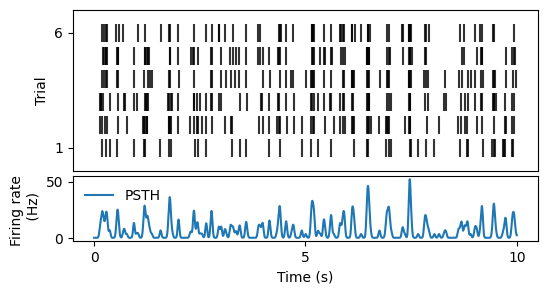

In [6]:
dt_s = dt  # your dt = 1e-4 seconds
spk_t_sec_test = [idx.detach().cpu().numpy() * dt_s for idx in spk_idx_test]  # list of arrays (sec)
psth_hz = spk_test.mean(axis=0) / dt_s   # [T] in Hz
t_sec = np.arange(spk_test.shape[1]) * dt_s


psth_hz_smooth = gaussian_filter1d(psth_hz, sigma=int(0.02 / dt_s))  # 20 ms smoothing


B, T = spk_test.shape
t_sec = np.arange(T) * dt_s
psth_hz = spk_test.mean(axis=0) / dt_s
psth_hz_smooth = gaussian_filter1d(psth_hz, sigma=max(1, int(0.02 / dt_s)))  # 20 ms

# Optional zoom window (seconds)
tmin, tmax = 0.0, min(5.0, t_sec[-1])  # first 5 seconds

fig, (ax_r, ax_p) = plt.subplots(
    2, 1, figsize=(6, 3),
    sharex=True,
    gridspec_kw={"height_ratios": [2.5, 1.0], "hspace": 0.05}
)

# Raster
ax_r.eventplot(
    spk_t_sec_test,
    lineoffsets=np.arange(1,B+1),
    linelengths=0.8,
    colors="k",
    alpha=0.8,
)
ax_r.set_ylabel("Trial")
ax_r.set_ylim(0, B+1)
ax_r.set_yticks([1,B])
ax_r.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
# ax_r.set_title("Spike raster")

# PSTH
# ax_p.plot(t_sec, psth_hz, alpha=0.35, label="PSTH (raw)")
ax_p.plot(t_sec, psth_hz_smooth, label="PSTH")
ax_p.set_ylabel("Firing rate \n (Hz)")
ax_p.set_xlabel("Time (s)")
ax_p.legend(frameon=False)
ax_p.set_xticks([0,5,10])

# ax_p.set_xlim(tmin, tmax)
plt.tight_layout()
plt.show()

# Design matrix

In [7]:
nLinearRFs = 10 #;     %number of stimulus basis functions
numShortSHFilts = 5#; %each is 0.4ms long - used for refractory period
nSHfilters = 7+numShortSHFilts#;%7+

nInh = 1#;
nExc = 1#

RFstart = 2e-3 #;%0?
RFend   = 150e-3#;%150e-3 or 180e-3;
b = 0.02
t, B_orth, B_raw = makeRaisedCosBasis(nLinearRFs, dt, [RFstart, RFend], b, zflag=0)
B_orth.shape

(2478, 10)

In [8]:
stimulus_t = torch.as_tensor(stimulus, dtype=torch.float64, device=device)
B_orth_t   = torch.as_tensor(B_orth,   dtype=torch.float64, device=device)
stimulus_t.shape, B_orth_t.shape

(torch.Size([11, 100000]), torch.Size([2478, 10]))

In [9]:
# stimulus_t: [B, T]
# basis_t: [L, P]
X_trials = [
    convolveStimulusWithBasis_torch(stimulus_t[b], B_orth_t, add_ones=True)  # -> [T, P+1]
    for b in range(stimulus_t.shape[0])
]
X_full = torch.stack(X_trials, dim=0)  # [B,T,D]
print('X_full:', X_full.shape)

X_full: torch.Size([11, 100000, 11])


## Intitialize CBEM linear

In [10]:
linmodel = CBEM_linear(binsize_s=dt).to(device)

cbem_lin, (steps_hist, loss_hist) = train_cbem_trials(
    linmodel,
    X_cond=X_full,
    basis_matrix= B_orth_t,
    spkTimes_bins=spk_idx_trials,
    lr=1e-1,
    conductance_penalty=None,
    n_steps=500,
    print_every=100,
    clip_grad_norm=1.0,
    window_size=None,  # or e.g. 20000
)


B_cond_lin = cbem_lin.B_cond.detach().cpu()

[train] Initialized B_cond with zeros with shape (11, 1)
model device: cpu
step     1 | loss 635.565 | data 635.565 | pen_w 0.000 | pen_sm 0.000 | mean rate 1.408 Hz


KeyboardInterrupt: 

## Evaluate

In [ ]:
plt.figure()
# steps_hist = np.array(steps_hist)
# loss_hist = np.array([l.detach().cpu().numpy() for l in loss_hist])
plt.plot(steps_hist, loss_hist, marker='o')
# plt.vlines([1000, 3000, 5000,6000], ymin = 0, ymax=10000)
plt.xlabel("Iteration (step)")
plt.ylabel("Penalized NLL")
plt.title("Training loss vs iteration")
plt.tight_layout()
plt.show()

In [ ]:
B = B_cond_lin          # [D,2]
W_orth = B[:-1, :]          # [P,2] learned coeffs in orth basis (drop bias row)
bias = B[-1, :]             # [2]

Borth = torch.as_tensor(B_orth, device=W_orth.device, dtype=W_orth.dtype)          # [L,P]
f_lin = Borth @ W_orth                                                  # [L,2]



## Full model using initial filt

In [ ]:
# @torch.no_grad()
# def pick_bias_for_target_rate(model, X_btd, biases=(0.0, 2.0, 5.0, 10.0, 20.0)):
#     bias_backup = model.B_cond[-1, :].detach().clone()   # save
#     out = []
#     try:
#         for b in biases:
#             model.B_cond[-1, :].fill_(float(b))
#             rate, _ = model(X_btd)
#             out.append((float(b), float(rate.mean())))
#     finally:
#         model.B_cond[-1, :].copy_(bias_backup)           # restore (even if error)
#     return out


In [ ]:
w_lin = B_cond_lin[:, 0].to(device)

model = CBEM_trials(binsize_s=dt).to(device)

with torch.no_grad():
    # force B_cond to be created with correct D
    _ = model(X_full[:, :1, :])   # any small slice works

    # Initialize model with learned filters
    model.B_cond[:, 0].copy_(w_lin)
    model.B_cond[:, 1].copy_(-w_lin)
    model.B_cond[-1, :].fill_(5.0)   # intercept bias (since last feature is ones)
    rate_bt, _ = model(X_full)  # [B,T]
    lam_bt = rate_bt * float(model.binsize_s)
    mean_rate_hz = float(rate_bt.mean())
    loss = cbem_penalized_nll_trials(
            model=model,
            X_btd=X_full,
            basis_matrix=B_orth_t,
            spk_bins_list=spk_idx_trials,
            window=None,
            conductance_penalty=None,
        )
print(f"Initial loss (no penalty) in full model| {loss:.2f}|mean rate: {mean_rate_hz:.2f}")

In [ ]:

trained, (steps_hist, loss_hist) = train_cbem_trials(
    model,
    X_cond=X_full,
    basis_matrix=B_orth_t,
    spkTimes_bins=spk_idx_trials,
    lr=1e-1,
    conductance_penalty=(1, 0.2, .1, 2),
    n_steps=2000,
    print_every=100,
    clip_grad_norm=1.0,
    window_size=None,  # or e.g. 20000
)

B_cond_learned = trained.B_cond.detach().cpu()

In [ ]:
# Training curve
plt.figure(figsize=(6, 3.5))
plt.plot(np.asarray(steps_hist), np.asarray(loss_hist), marker='o')
plt.xlabel('Iteration (step)')
plt.ylabel('Penalized NLL (avg over trials)')
plt.title('Training loss vs iteration')
plt.tight_layout()
plt.show()

In [ ]:
# Learned conductance filters in time domain
B = trained.B_cond.detach().cpu()   # [D, 2]
np.savez("B_trained", B)
W_orth = B[:-1, :]                  # drop bias row

Borth = torch.as_tensor(B_orth, dtype=W_orth.dtype)
filters = Borth @ W_orth            # [L, 2]

t_ms = np.arange(filters.shape[0]) * dt * 1e3

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot(t_ms, filters[:, 0].numpy(), lw=2.0)
axes[0].set_title('Learned Excitatory Filter')
axes[0].set_xlabel('Lag (ms)')

axes[1].plot(t_ms, filters[:, 1].numpy(), lw=2.0)
axes[1].set_title('Learned Inhibitory Filter')
axes[1].set_xlabel('Lag (ms)')

for ax in axes:
    ax.axhline(0.0, color='k', lw=0.8, alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
with torch.no_grad():
    Xuse = X_full[:, :20000, :]
    x = torch.einsum("btd,dk->btk", Xuse, model.B_cond)  # [B,T,2]
    corr = torch.corrcoef(torch.stack([x[...,0].flatten(), x[...,1].flatten()]))[0,1]
    print("corr(x_exc, x_inh):", float(corr))

## Evaluate trained model

In [ ]:
trained.eval()

##Design Matrix test stim
stim_test_t = torch.as_tensor(stimulus_test, dtype=torch.float64, device=device)

# stimulus_t: [B, T]
# basis_t: [L, P]
X_test_tr = [
    convolveStimulusWithBasis_torch(stim_test_t[b], B_orth_t, add_ones=True)  # -> [T, P+1]
    for b in range(stimulus_test.shape[0])
]
X_test = torch.stack(X_test_tr, dim=0)  # [B,T,D]
print('X_full:', X_test.shape)

## LIN MODEL STATS
with torch.no_grad():
    psth_lin, aux_lin = cbem_lin(X_test)  # [B,T]
    
## FULL MODEL
with torch.no_grad():
    rate_test, aux = trained(X_test)  # [B,T]
B = X_test.shape[0]
T0 = 500
Y_init = torch.zeros(B, T0, device=X_test.device, dtype=X_test.dtype)  # [B,T0]
sps_t = trained.simulateSpikeTrains_trials(X_test, Y_init, seed=0).detach().cpu().numpy()
loss = cbem_penalized_nll_trials(
            model=trained,
            X_btd=X_test,
            basis_matrix=B_orth_t,
            spk_bins_list=spk_idx_test,
            window=None,
            conductance_penalty=None,)
print(loss)

In [ ]:
gs = aux['gs']
gs.shape

In [ ]:
rate_hat = rate_test.detach().cpu()
rate_lin = psth_lin.detach().cpu()

rate_hat = gaussian_smooth(rate_hat[0], sigma_bins=max(1, int(0.02 / dt_s)))  # 20 ms
rate_lin = gaussian_smooth(rate_lin[0], sigma_bins=max(1, int(0.02 / dt_s)))  # 20 ms

In [ ]:
# sps: [B,T] in {0,1}
B, T = sps_t.shape

pltLength_bins = 70000
t_ms = np.arange(pltLength_bins) * dt * 1e3

# Build spike times (ms) per trial for eventplot
spkTimes_ms_by_trial = [
    np.where(sps_t[b, :pltLength_bins] > 0)[0] * dt * 1e3
    for b in range(B)
]
# spk_idx_test = [
#     torch.as_tensor((sps_t[b] > 0).nonzero()[0], device=X_full.device, dtype=torch.long)
#     for b in range(B)
# ]

fig, ax = plt.subplots(figsize=(12, 5))

# Raster: each row is a trial
ax.eventplot(
    spkTimes_ms_by_trial,
    lineoffsets=np.arange(B),   # y position per trial
    linelengths=0.8,
    colors="k",
    alpha=0.8,
)

ax.set_xlabel("time (ms)")
ax.set_ylabel("trial")
ax.set_yticks(np.arange(B))
ax.set_ylim(-1, B)
ax.set_xlim(t_ms[0], t_ms[-1])

# Optional zoom (same window you used before)
# ax.set_xlim(4000, 5000)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import explained_variance_score

ev_full = explained_variance_score(psth_hz_smooth, rate_hat)
ev_lin  = explained_variance_score(psth_hz_smooth, rate_lin)

print(ev_full, ev_lin)

In [ ]:
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

r2_full = r2_score(psth_hz_smooth, rate_hat)
r2_lin  = r2_score(psth_hz_smooth, rate_lin)

T = rate_lin.shape[0]
t_sec = np.arange(T) * dt_s * 1e3

plt.figure(figsize=(8,4))
plt.title(fr"$R^2$ Exc: {r2_lin:.2f}, $R^2$ exc + inh {r2_full:.2f}")

plt.plot(t_sec, psth_hz_smooth, lw=2.0, c='k', label='Response', alpha=0.3)
plt.fill_between(t_sec, 0, psth_hz_smooth, color='k', alpha=0.15)

plt.plot(t_sec, rate_hat, label='Exc + Inh')
plt.plot(t_sec, rate_lin, label='Exc only')

plt.ylabel("Firing Rate (Hz)")
plt.xlabel("Time (ms)")
plt.xlim(6e3, 8e3)
plt.legend()
plt.show()

## TODO:
- Spike history!

In [ ]:
import torch

save_path = "fuck_yeah.pt"

ckpt = {
    "model_state_dict": trained.state_dict(),
    "dt": float(dt),
    "binsize_s": float(trained.binsize_s),
    "steps_hist": steps_hist,
    "loss_hist": loss_hist,
    # optional: save learned weights explicitly
    "B_cond": trained.B_cond.detach().cpu(),
}

torch.save(ckpt, save_path)
print("saved to:", save_path)